In [28]:
import os
import json
import pickle
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt



from datetime import datetime
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras import layers, Model, regularizers

!pip install scikit-learn==1.6.1


print("TensorFlow:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.20.0
GPU available: True


In [29]:
CSV_PATH = '/content/skopje_air_quality_historical_CLEANED.csv'
TARGET_COL = 'pm10'

LOOKBACK = 48
HORIZON = 24
OFFSET = 24  #  predicts t+25..t+48

TOP_K_FEATURES = 15
USE_RF_SELECTION = False

EPOCHS = 40
BATCH_SIZE = 128
LR = 3e-4
SEED = 42


MODEL_TAG = "h25_48"

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [30]:
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

if 'datetime' not in df.columns:
    raise ValueError("Expected 'datetime' column in CSV.")

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').set_index('datetime')

if 'timestamp' in df.columns:
    df = df.drop(columns=['timestamp'])

# cyclical time features
if 'hour_sin' not in df.columns or 'hour_cos' not in df.columns:
    hours = df.index.hour
    df['hour_sin'] = np.sin(2*np.pi*hours/24)
    df['hour_cos'] = np.cos(2*np.pi*hours/24)

if 'day_sin' not in df.columns or 'day_cos' not in df.columns:
    days = df.index.dayofweek
    df['day_sin'] = np.sin(2*np.pi*days/7)
    df['day_cos'] = np.cos(2*np.pi*days/7)


In [31]:
def add_dynamic_features(dfin: pd.DataFrame):
    d = dfin.copy()
    base_cols = ['pm10', 'pm2_5', 'aqi', 'co', 'no2']
    for col in base_cols:
        if col not in d.columns:
            continue
        d[f'{col}_diff1'] = d[col].diff(1)
        d[f'{col}_diff3'] = d[col].diff(3)
        d[f'{col}_diff6'] = d[col].diff(6)
        for w in [3, 6, 12, 24]:
            d[f'{col}_roll{w}_mean'] = d[col].rolling(w).mean()
            d[f'{col}_roll{w}_std'] = d[col].rolling(w).std()

    eps = 1e-6
    if 'pm10' in d.columns:
        d['pm10_mom24'] = d['pm10'] / (d['pm10_roll24_mean'] + eps)
        d['pm10_absdiff1'] = np.abs(d['pm10_diff1'])
        d['pm10_absdiff3'] = np.abs(d['pm10_diff3'])

    return d.dropna()

df_feat = add_dynamic_features(df)
print("Feature-engineered shape:", df_feat.shape)

Feature-engineered shape: (46656, 67)


In [32]:
def select_features_for_pm10(
    df_features: pd.DataFrame,
    target_col: str = 'pm10',
    top_k: int = 15,
    force_keep=None,
    random_state: int = 42,
    offset: int = 24
):
    """
    <<< CHANGED:
    For h25-48 model, feature relevance should reflect farther horizon.
    Instead of y(t+1), use y(t+offset+1). For offset=24 -> shift(-25).
    """
    if force_keep is None:
        force_keep = ['pm10', 'pm2_5', 'aqi', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

    d = df_features.copy().dropna()


    y_future = d[target_col].shift(-(offset + 1))
    X = d.drop(columns=[target_col])
    data = pd.concat([X, y_future.rename('y_future')], axis=1).dropna()

    X = data.drop(columns=['y_future'])
    y = data['y_future']

    split = int(len(X) * 0.8)
    X_train, y_train = X.iloc[:split], y.iloc[:split]

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

    selected = []
    for f in force_keep:
        if f in d.columns and f not in selected:
            selected.append(f)

    for f in imp.index:
        if f not in selected:
            selected.append(f)
        if len(selected) >= top_k:
            break

    if target_col not in selected:
        selected = [target_col] + selected
    else:
        selected = [target_col] + [c for c in selected if c != target_col]

    selected = selected[:top_k]
    return selected, imp


manual_features = [
    'pm10', 'pm2_5', 'aqi', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'pm10_diff1', 'pm10_absdiff1', 'pm2_5_diff1', 'co_diff3',
    'pm10_roll3_std', 'co_diff1', 'pm10_diff3'
]

manual_features = [c for c in manual_features if c in df_feat.columns]
selected_cols = manual_features

if USE_RF_SELECTION:
    force_core = ['pm10', 'pm2_5', 'aqi', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
    selected_cols, importance = select_features_for_pm10(
        df_features=df_feat,
        target_col=TARGET_COL,
        top_k=TOP_K_FEATURES,
        force_keep=force_core,
        random_state=SEED,
        offset=OFFSET  # <<< CHANGED
    )
    print("\nSelected features (RF):", selected_cols)
    print("\nTop importances:")
    display(importance.head(20))
else:
    selected_cols = manual_features
    print("\nSelected features (manual):", selected_cols)

# optional anti-flatline safeguard
if 'pm10_roll3_mean' in selected_cols:
    print("\nNote: removing pm10_roll3_mean to reduce mean-regression risk.")
    selected_cols = [c for c in selected_cols if c != 'pm10_roll3_mean']
    for c in manual_features:
        if c not in selected_cols:
            selected_cols.append(c)
        if len(selected_cols) >= min(TOP_K_FEATURES, 15):
            break

df_selected = df_feat[selected_cols].dropna()
print("\nFinal selected feature count:", len(df_selected.columns))
print(df_selected.columns.tolist())



Selected features (manual): ['pm10', 'pm2_5', 'aqi', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'pm10_diff1', 'pm10_absdiff1', 'pm2_5_diff1', 'co_diff3', 'pm10_roll3_std', 'co_diff1', 'pm10_diff3']

Final selected feature count: 14
['pm10', 'pm2_5', 'aqi', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'pm10_diff1', 'pm10_absdiff1', 'pm2_5_diff1', 'co_diff3', 'pm10_roll3_std', 'co_diff1', 'pm10_diff3']


In [33]:
feature_cols = list(df_selected.columns)
if TARGET_COL not in feature_cols:
    raise ValueError(f"TARGET_COL '{TARGET_COL}' missing from selected features.")

target_idx = feature_cols.index(TARGET_COL)

scaler = RobustScaler()
data_scaled = scaler.fit_transform(df_selected.values)

def make_sequences(data, target_col_idx, lookback=48, horizon=24, offset=24):
    """
    <<< CHANGED:
    Input window: [i-lookback, i)
    Target window: [i+offset, i+offset+horizon)
    For offset=24,horizon=24 => predict hours 25..48 ahead.
    """
    X, y = [], []
    max_i = len(data) - offset - horizon + 1  # safe upper bound
    for i in range(lookback, max_i):
        X.append(data[i-lookback:i, :])
        y.append(data[i+offset:i+offset+horizon, target_col_idx])
    return np.array(X), np.array(y)

X, y = make_sequences(
    data_scaled,
    target_idx,
    lookback=LOOKBACK,
    horizon=HORIZON,
    offset=OFFSET  # <<< CHANGED
)

print("X shape:", X.shape, "y shape:", y.shape)

# chronological split
n = len(X)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


X shape: (46561, 48, 14) y shape: (46561, 24)
Train: (32592, 48, 14) (32592, 24)
Val  : (6984, 48, 14) (6984, 24)
Test : (6985, 48, 14) (6985, 24)


In [34]:
@tf.keras.utils.register_keras_serializable(package="pm10")
class PeakRampLoss(tf.keras.losses.Loss):
    def __init__(self, q75, peak_w=1.8, ramp_w=0.8, name="peak_ramp_loss",
                 reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE, **kwargs):
        super().__init__(name=name, reduction=reduction, **kwargs)
        self.q75 = tf.constant(q75, dtype=tf.float32)
        self.peak_w = peak_w
        self.ramp_w = ramp_w

    def call(self, y_true, y_pred):
        abs_err = tf.abs(y_true - y_pred)

        peak_mask = tf.cast(y_true >= self.q75, tf.float32)
        w_peak = 1.0 + peak_mask * (self.peak_w - 1.0)

        dy_true = tf.abs(y_true[:, 1:] - y_true[:, :-1])
        dy_true = tf.concat([dy_true[:, :1], dy_true], axis=1)
        w_ramp = 1.0 + self.ramp_w * tf.tanh(dy_true)

        w = w_peak * w_ramp
        return tf.reduce_mean(w * abs_err)

    def get_config(self):
        config = super().get_config()
        config.update({
            "q75": float(self.q75.numpy()) if hasattr(self.q75, "numpy") else float(self.q75),
            "peak_w": self.peak_w,
            "ramp_w": self.ramp_w,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [35]:
def build_lean_model(lookback, n_features, horizon):
    inp = layers.Input(shape=(lookback, n_features))

    x = layers.Conv1D(
        filters=48, kernel_size=3, padding='causal', activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(inp)
    x = layers.Dropout(0.20)(x)

    x = layers.Bidirectional(
        layers.LSTM(48, return_sequences=True, dropout=0.15, recurrent_dropout=0.0)
    )(x)

    # attention pooling (no raw tf op)
    score = layers.Dense(1, activation='tanh')(x)       # (B,T,1)
    score = layers.Softmax(axis=1)(score)               # (B,T,1)
    weighted = layers.Multiply()([x, score])            # (B,T,F)
    # use GlobalAveragePooling on weighted sequence to avoid Lambda deserialization issues
    ctx = layers.GlobalAveragePooling1D()(weighted)

    x = layers.Dense(96, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(ctx)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(horizon)(x)

    return Model(inp, out)

q75 = np.quantile(y_train, 0.75).astype(np.float32)
loss_fn = PeakRampLoss(q75=q75, peak_w=1.4, ramp_w=0.4)

model = build_lean_model(LOOKBACK, X_train.shape[-1], HORIZON)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0),
    loss=loss_fn,
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')]
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 48, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 48, 48)    │      2,064 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 48, 48)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 48, 96)    │     37,248 │ dropout_4[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 48, 1)     │         97 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_2 (Softmax) │ (None, 48, 1)     │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 48, 96)    │          0 │ bidirectional_2[… │
│ (Multiply)          │                   │            │ softmax_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 96)        │          0 │ multiply_2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 96)        │      9,312 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 96)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 24)        │      2,328 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,049 (199.41 KB)

 Trainable params: 51,049 (199.41 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=5e-6, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        f'/content/best_lean_pm10_{MODEL_TAG}.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.1454 - mae: 0.8239
Epoch 1: val_loss improved from None to 1.42627, saving model to /content/best_lean_pm10_h25_48.keras

Epoch 1: finished saving model to /content/best_lean_pm10_h25_48.keras
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - loss: 1.1138 - mae: 0.8101 - val_loss: 1.4263 - val_mae: 1.0276 - learning_rate: 3.0000e-04
Epoch 2/40
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0185 - mae: 0.7662
Epoch 2: val_loss improved from 1.42627 to 1.32255, saving model to /content/best_lean_pm10_h25_48.keras

Epoch 2: finished saving model to /content/best_lean_pm10_h25_48.keras
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 1.0154 - mae: 0.7644 - val_loss: 1.3226 - val_mae: 0.9677 - learning_rate: 3.0000e-04
Epoch 3/40
251/255 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9831 - mae: 0.7451
Epoch 3: val_loss improved from 1.32255 to 1.27605, saving model to /content/best_lean_pm10_h25_48.keras

Epoch 3: finished saving

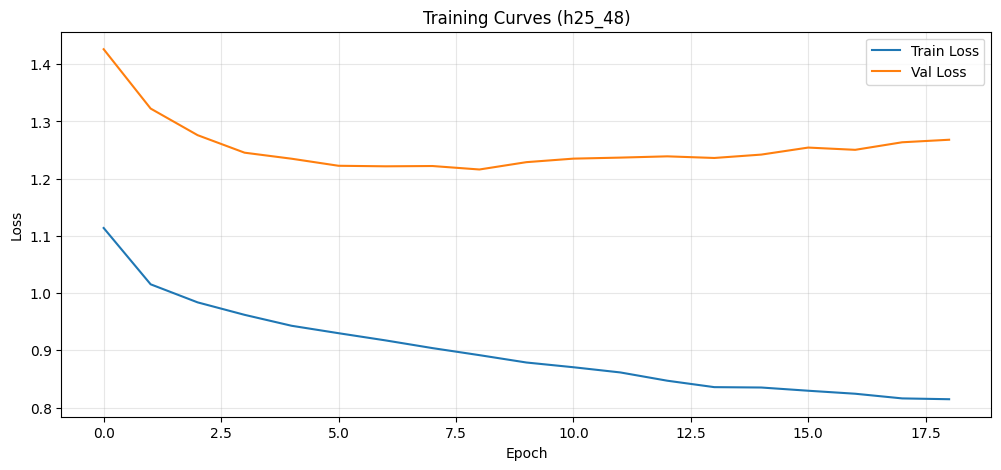

In [37]:
plt.figure(figsize=(12,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title(f'Training Curves ({MODEL_TAG})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

=== FINAL METRICS (h25_48, real µg/m³) ===
MAE       : 5.5148
RMSE      : 8.9642
sMAPE (%) : 63.8008
Peak MAE  : 8.8503 (true >= Q75)
Ramp MAE  : 0.4406


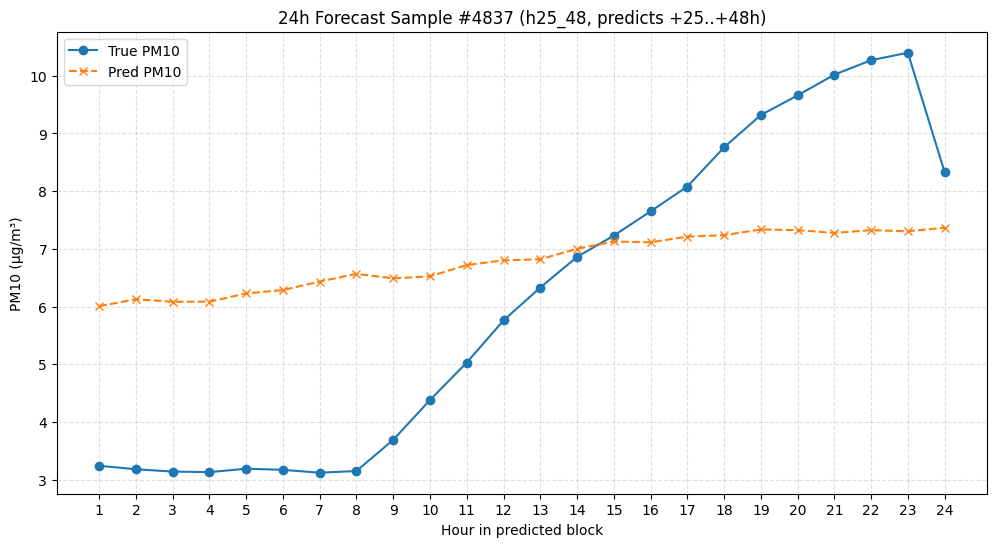

In [38]:
def inverse_target_only(y_scaled_2d, scaler_obj, n_features, target_col_idx):
    out = []
    for i in range(len(y_scaled_2d)):
        dummy = np.zeros((y_scaled_2d.shape[1], n_features))
        dummy[:, target_col_idx] = y_scaled_2d[i]
        inv = scaler_obj.inverse_transform(dummy)[:, target_col_idx]
        out.append(inv)
    return np.array(out)

def smape(y_true, y_pred, eps=1e-6):
    return np.mean(2.0*np.abs(y_true-y_pred)/(np.abs(y_true)+np.abs(y_pred)+eps))*100

y_pred_scaled = model.predict(X_test, verbose=1)

n_features = len(feature_cols)
y_test_real = inverse_target_only(y_test, scaler, n_features, target_idx)
y_pred_real = inverse_target_only(y_pred_scaled, scaler, n_features, target_idx)

mae = mean_absolute_error(y_test_real.flatten(), y_pred_real.flatten())
rmse = np.sqrt(mean_squared_error(y_test_real.flatten(), y_pred_real.flatten()))
smape_v = smape(y_test_real, y_pred_real)

q75_real = np.quantile(y_test_real, 0.75)
peak_mask = y_test_real >= q75_real
peak_mae = np.mean(np.abs(y_test_real[peak_mask] - y_pred_real[peak_mask]))

d_true = np.abs(np.diff(y_test_real, axis=1))
d_pred = np.abs(np.diff(y_pred_real, axis=1))
ramp_mae = np.mean(np.abs(d_true - d_pred))

print(f"\n=== FINAL METRICS ({MODEL_TAG}, real µg/m³) ===")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"sMAPE (%) : {smape_v:.4f}")
print(f"Peak MAE  : {peak_mae:.4f} (true >= Q75)")
print(f"Ramp MAE  : {ramp_mae:.4f}")

# sample plot
idx = random.randint(0, len(y_test_real)-1)
plt.figure(figsize=(12,6))
plt.plot(range(1, HORIZON+1), y_test_real[idx], marker='o', label='True PM10')
plt.plot(range(1, HORIZON+1), y_pred_real[idx], marker='x', linestyle='--', label='Pred PM10')
plt.title(f'24h Forecast Sample #{idx} ({MODEL_TAG}, predicts +25..+48h)')
plt.xlabel('Hour in predicted block')
plt.ylabel('PM10 (µg/m³)')
plt.xticks(range(1, HORIZON+1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

In [39]:
ARTIFACT_DIR = "/content/pm10_artifacts_48h"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

run_name = f"pm10_lean_{MODEL_TAG}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

# save model
model_path = os.path.join(ARTIFACT_DIR, f"{run_name}.keras")
model.save(model_path)

# save scaler
scaler_path = os.path.join(ARTIFACT_DIR, f"{run_name}_scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

# save feature importance
importance_path = None
if USE_RF_SELECTION:
    importance_path = os.path.join(ARTIFACT_DIR, f"{run_name}_feature_importance.csv")
    importance.sort_values(ascending=False).to_csv(importance_path, header=["importance"])

# save metadata
meta = {
    "run_name": run_name,
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_path": model_path,
    "scaler_path": scaler_path,
    "feature_importance_path": importance_path,
    "target_col": TARGET_COL,
    "target_idx": int(target_idx),
    "feature_cols": feature_cols,
    "n_features": int(len(feature_cols)),
    "lookback": int(LOOKBACK),
    "horizon_trained": int(HORIZON),
    "offset": int(OFFSET),  # <<< CHANGED
    "target_window": "t+25..t+48" if OFFSET == 24 and HORIZON == 24 else f"t+{OFFSET+1}..t+{OFFSET+HORIZON}",
    "notes": f"Lean CNN+BiLSTM+attention pooling, shifted target offset={OFFSET}"
}
meta_path = os.path.join(ARTIFACT_DIR, f"{run_name}_meta.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

# selected features file
features_path = os.path.join(ARTIFACT_DIR, f"{run_name}_selected_features.json")
with open(features_path, "w") as f:
    json.dump({"selected_features": feature_cols}, f, indent=2)

# append log
log_file = '/content/experiments_log.csv'
experiment_name = f'LEAN_CNN_BiLSTM_Attn_PeakRampLoss_{MODEL_TAG}'

log_data = {
    'date': [datetime.now().strftime("%Y-%m-%d %H:%M:%S")],
    'model_name': [experiment_name],
    'lookback': [LOOKBACK],
    'horizon': [HORIZON],
    'offset': [OFFSET],  # <<< CHANGED
    'target_window': [meta["target_window"]],
    'num_features': [len(feature_cols)],
    'selected_features': [", ".join(feature_cols)],
    'mae': [round(float(mae), 4)],
    'rmse': [round(float(rmse), 4)],
    'smape': [round(float(smape_v), 4)],
    'peak_mae': [round(float(peak_mae), 4)],
    'ramp_mae': [round(float(ramp_mae), 4)],
    'notes': [f'Chronological split; RobustScaler; shifted target offset={OFFSET}']
}
new_log_df = pd.DataFrame(log_data)

if os.path.isfile(log_file):
    new_log_df.to_csv(log_file, mode='a', index=False, header=False)
else:
    new_log_df.to_csv(log_file, index=False)

print("\n✅ Artifacts saved:")
print("Model :", model_path)
print("Scaler:", scaler_path)
print("Meta  :", meta_path)
print("Feats :", features_path)
if importance_path:
    print("RF imp:", importance_path)


✅ Artifacts saved:
Model : /content/pm10_artifacts_48h/pm10_lean_h25_48_20260508_192323.keras
Scaler: /content/pm10_artifacts_48h/pm10_lean_h25_48_20260508_192323_scaler.pkl
Meta  : /content/pm10_artifacts_48h/pm10_lean_h25_48_20260508_192323_meta.json
Feats : /content/pm10_artifacts_48h/pm10_lean_h25_48_20260508_192323_selected_features.json
